# Intelligent Automation 2026/27- Assignment 1

To be delivered until 2026-10-09 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `feature_description.txt`.

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("mathematics_grades.csv")

df.head(357)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,failed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352,MS,M,20,U,LE3,A,2,2,services,services,...,5,4,4,5,4,11,9,9,9,True
353,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,3,14,16,16,False
354,MS,M,21,R,GT3,T,1,1,other,other,...,5,3,3,3,3,3,10,8,7,True
355,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,0,11,12,10,False


##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [3]:
# Ordinal categorical variables
ordinal_cols = [
    "Medu", "Fedu", "traveltime", "studytime",
    "famrel", "freetime", "goout", "Dalc",
    "Walc", "health"
]

# Numerical discrete variables
numeric_disc_cols = [
    "age", "failures", "absences",
    "G1", "G2", "G3"
]

# Numerical continuous variables
numeric_cont_cols = []

# Binary categorical variables
binary_cols = [
    "school", "sex", "address", "famsize",
    "Pstatus", "schoolsup", "famsup", "paid",
    "activities", "nursery", "higher",
    "internet", "romantic"
]

# Nominal categorical variables
nominal_cols = [
    "Mjob", "Fjob", "reason", "guardian"
]

# Boolean variable
boolean_cols = ["failed"]

# Identify the feature type of each variable
summary_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Feature Type": [
        "Ordinal categorical" if col in ordinal_cols
        else "Numerical discrete" if col in numeric_disc_cols
        else "Numerical continuous" if col in numeric_cont_cols
        else "Binary categorical" if col in binary_cols
        else "Boolean" if col in boolean_cols
        else "Nominal categorical"
        for col in df.columns
    ]
})

display(summary_df)


,Data Type,Feature Type
school,object,Binary categorical
sex,object,Binary categorical
age,int64,Numerical discrete
address,object,Binary categorical
famsize,object,Binary categorical
Pstatus,object,Binary categorical
Medu,int64,Ordinal categorical
Fedu,int64,Ordinal categorical
Mjob,object,Nominal categorical
Fjob,object,Nominal categorical


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [6]:
print(df.isnull().sum())


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
failed        0
dtype: int64


##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

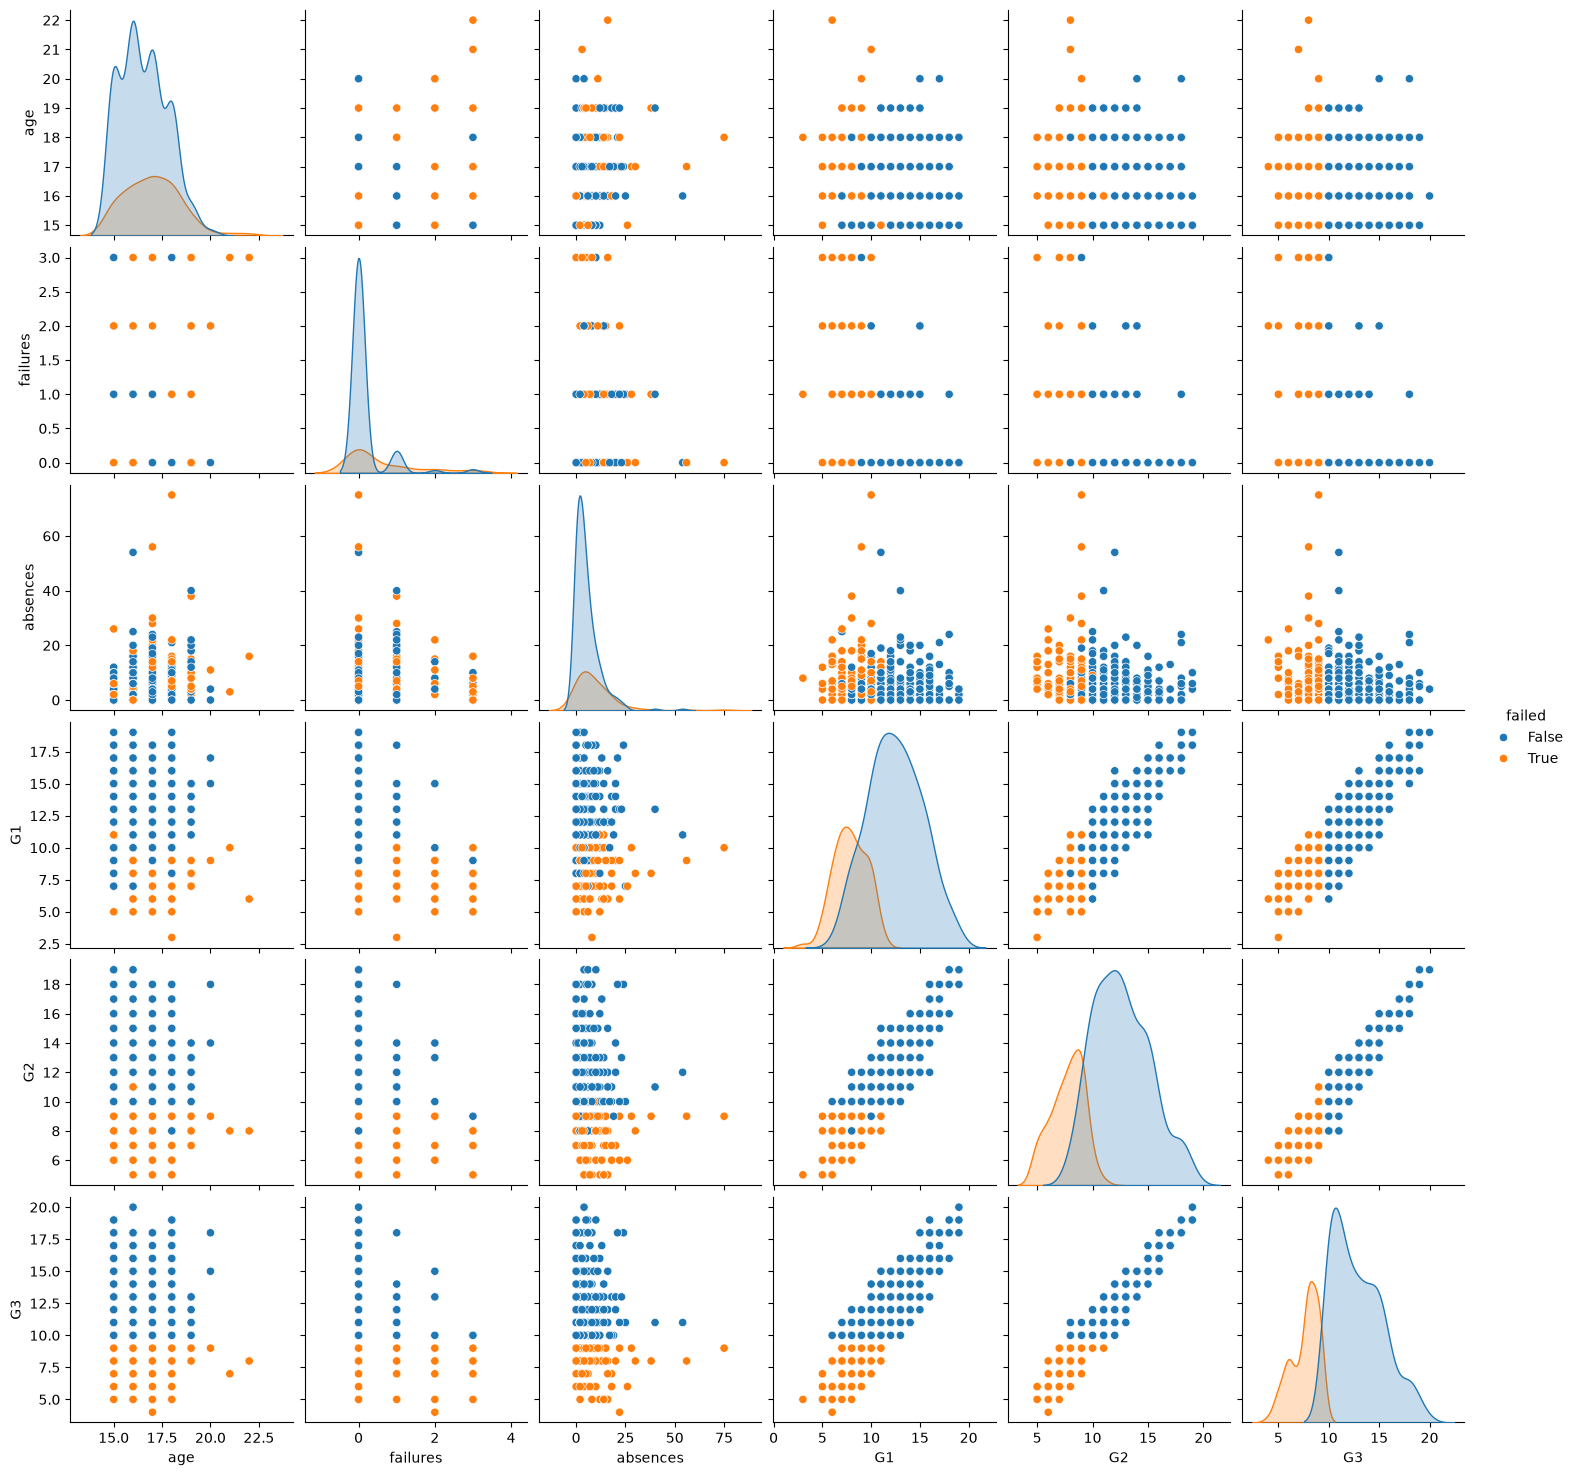

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt



numerical_variables = numeric_disc_cols + numeric_cont_cols


sns.pairplot(df, vars=numerical_variables, hue='failed')

plt.show()

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

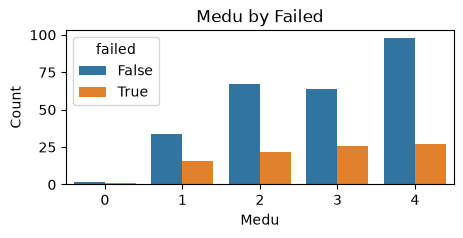

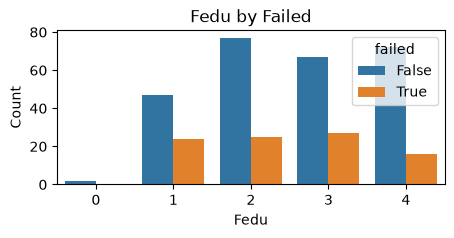

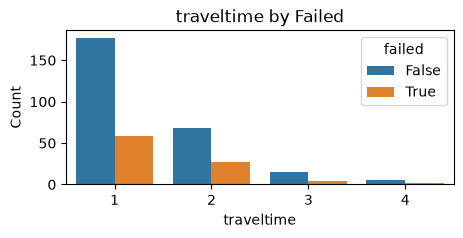

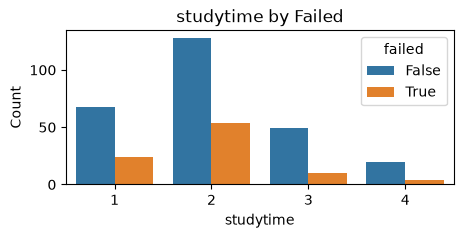

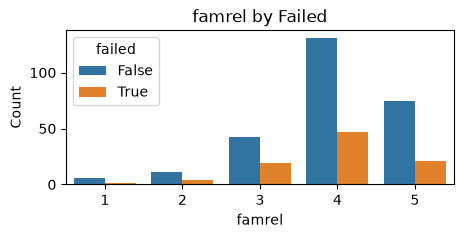

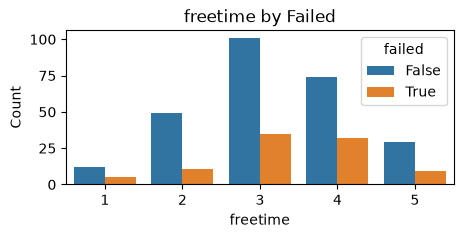

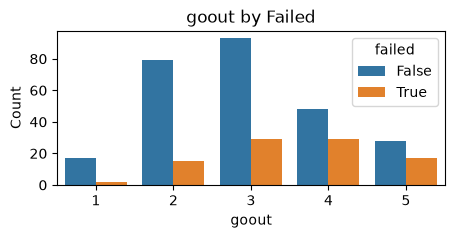

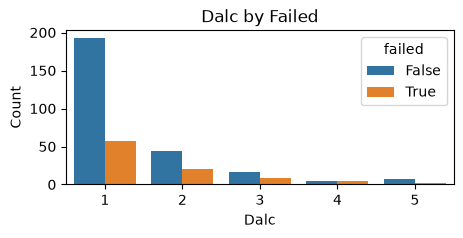

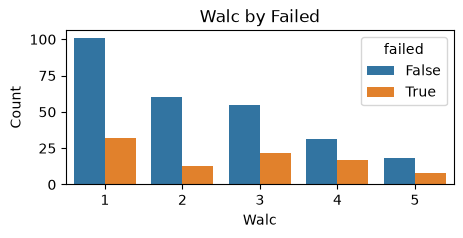

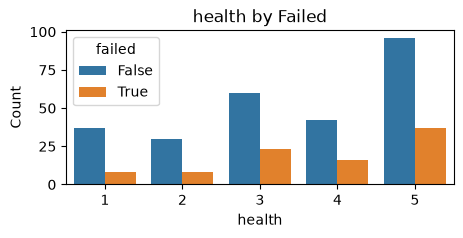

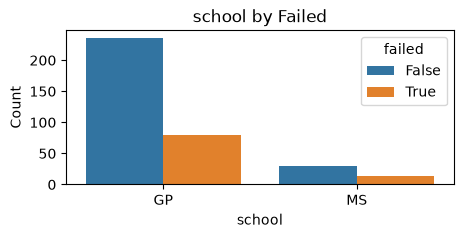

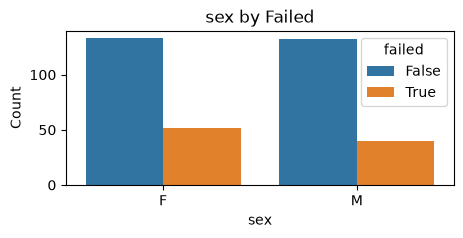

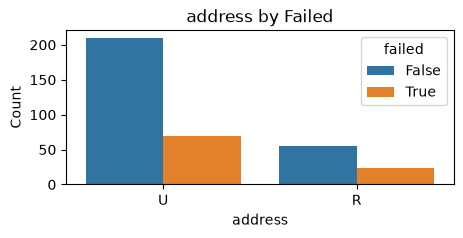

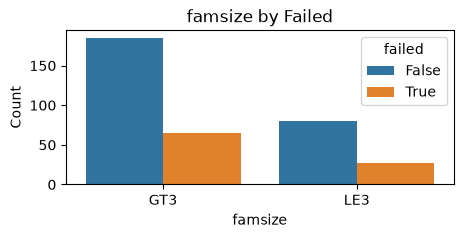

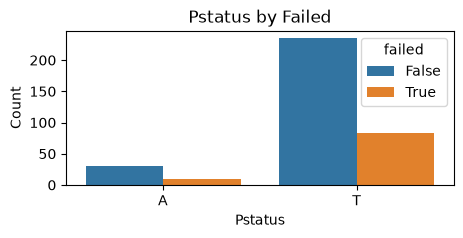

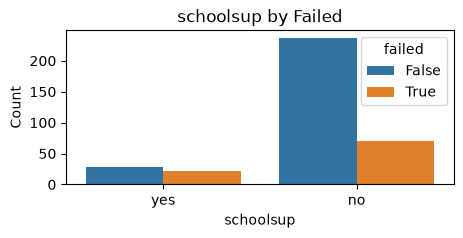

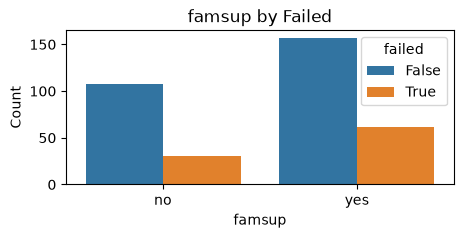

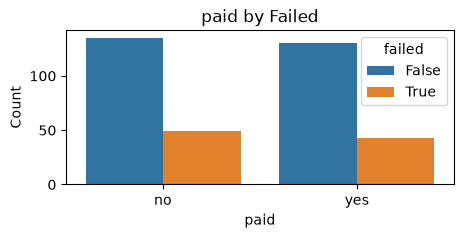

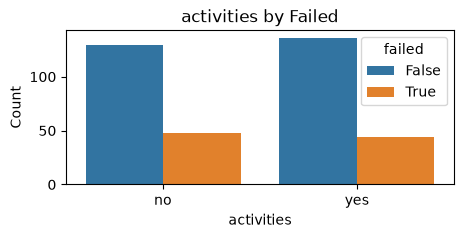

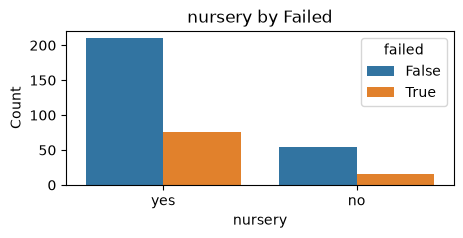

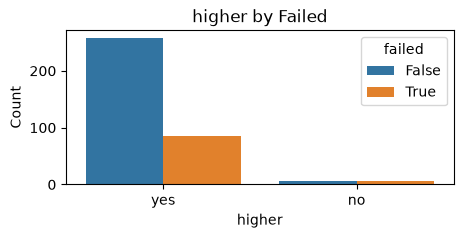

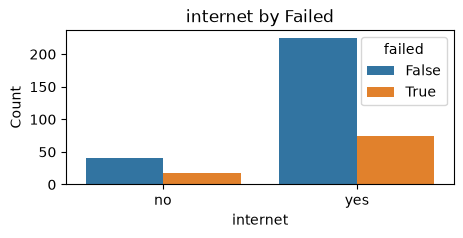

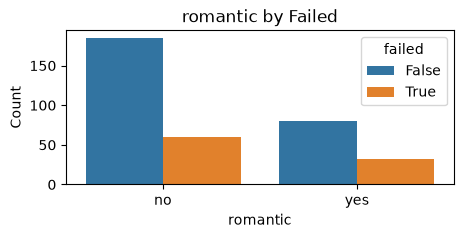

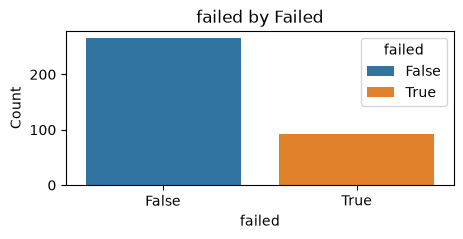

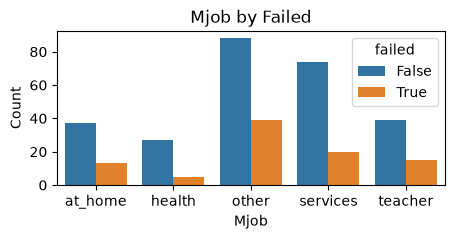

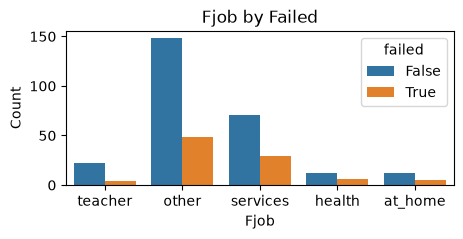

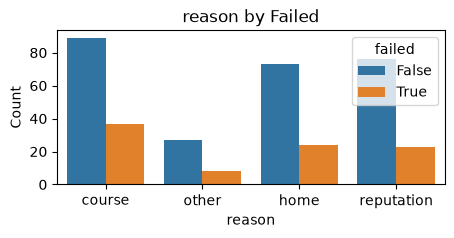

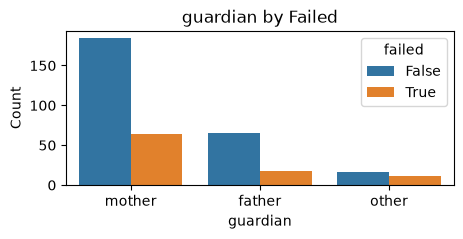

In [8]:

categorical_variables = ordinal_cols + boolean_cols + nominal_cols


for variable in categorical_variables:
    plt.figure(figsize=(5, 2))
    
    sns.countplot(data=df, x=variable, hue='failed')
    
    plt.title(f'{variable} by Failed')
    plt.xlabel(variable)
    plt.ylabel('Count')
    plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [9]:
rural_no_internet = df[(df['address'] == 'R') & (df['internet'] == 'no')]

counts_by_school = rural_no_internet.groupby('school').size()
print("Number of rural students without internet by school:") 
print(counts_by_school)

Number of rural students without internet by school:
school
GP    17
MS     7
dtype: int64


##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [11]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.20, random_state=10)

print("Training set:", train.shape)
print("Test set:", test.shape)

Training set: (285, 34)
Test set: (72, 34)


# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

The most important metric is Recall (minimizing the False Negative Rate). In an academic support setting, a False Negative(predicting a student will pass when they actually fail) is far worse than a False Positive because the student is missed by early-warning systems and receives no remedial help. Maximizing Recall ensures the safety net identifies as many struggling students as possible.


##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

In [17]:
import random
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score )

X_train = train[['absences']]
X_test = test[['absences']]
y_train = train['failed']
y_test = test['failed']


model = LogisticRegression(random_state=10)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Confusion Matrix (rows=actual, cols=predicted):")
print(cm)
print(f"\nAccuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

Confusion Matrix (rows=actual, cols=predicted):
[[56  1]
 [13  2]]

Accuracy: 0.8056
Precision: 0.6667
Recall: 0.1333
F1-score: 0.2222


##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

The model likely performs poorly because absences alone are not enough to predict whether a student will pass or fail. There may be considerable overlap in absences between students who pass and fail, making it difficult for the model to distinguish between them.

The failed variable may also be imbalanced, with more students passing than failing. This can result in good accuracy while still missing students who actually fail.

The model could be improved by including more relevant predictors, such as previous grades, study time, and previous failures. If the classes are imbalanced, techniques such as class weighting or oversampling could also improve the model, particularly its recall.


##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

In [18]:


X_train = train[['studytime']]
X_test = test[['studytime']]
y_train = train['failed']
y_test = test['failed']

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[43 14]
 [10  5]]
Accuracy: 0.6666666666666666
Precision: 0.2631578947368421
Recall: 0.3333333333333333
F1-score: 0.29411764705882354


##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert studytime into a categorical variable using one-hot encoding
X_train = pd.get_dummies(train[['studytime']], columns=['studytime'], dtype=int)
X_test = pd.get_dummies(test[['studytime']], columns=['studytime'], dtype=int)

# Make sure train and test have exactly the same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train['failed']
y_test = test['failed']

# Logistic regression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Confusion Matrix:
[[11 42]
 [ 4 15]]
Accuracy: 0.3611111111111111
Precision: 0.2631578947368421
Recall: 0.7894736842105263
F1-score: 0.39473684210526316


##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


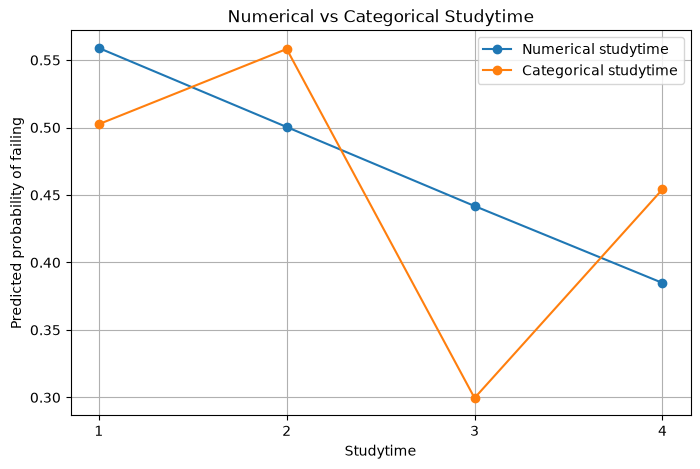

In [48]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# -------------------------
# Numerical model
# -------------------------
X_train_num = train[['studytime']]
X_test_num = test[['studytime']]
y_train = train['failed']
y_test = test['failed']

model_num = LogisticRegression(class_weight='balanced')
model_num.fit(X_train_num, y_train)

# -------------------------
# Categorical model
# -------------------------
X_train_cat = pd.get_dummies(
    train[['studytime']],
    columns=['studytime'],
    dtype=int
)

X_test_cat = pd.get_dummies(
    test[['studytime']],
    columns=['studytime'],
    dtype=int
)

X_test_cat = X_test_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

model_cat = LogisticRegression(class_weight='balanced')
model_cat.fit(X_train_cat, y_train)

# -------------------------
# Predictions over studytime
# -------------------------
studytime_values = sorted(test['studytime'].unique())

# Numerical
X_plot_num = pd.DataFrame({'studytime': studytime_values})
pred_num = model_num.predict_proba(X_plot_num)[:, 1]

# Categorical
X_plot_cat = pd.DataFrame({'studytime': studytime_values})
X_plot_cat = pd.get_dummies(
    X_plot_cat,
    columns=['studytime'],
    dtype=int
)
X_plot_cat = X_plot_cat.reindex(
    columns=X_train_cat.columns,
    fill_value=0
)

pred_cat = model_cat.predict_proba(X_plot_cat)[:, 1]

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    studytime_values,
    pred_num,
    marker='o',
    label='Numerical studytime'
)

plt.plot(
    studytime_values,
    pred_cat,
    marker='o',
    label='Categorical studytime'
)

plt.xlabel('Studytime')
plt.ylabel('Predicted probability of failing')
plt.title('Numerical vs Categorical Studytime')
plt.xticks(studytime_values)
plt.legend()
plt.grid()
plt.show()

The two models differ in how the `studytime` variable is represented. In the first model (2.4), `studytime` is treated as a numerical variable. Therefore, the model assumes that the difference between consecutive studytime values is constant. The predicted probability of failing decreases as studytime increases.

In the second model (2.5), `studytime` is treated as a categorical variable using one-hot encoding. This means that each studytime value is treated as a separate category, without assuming that the categories have an ordered or linear effect. As a result, the predicted probability of failing can vary independently between studytime categories.

For the numerical model, the predicted probabilities of failing for studytime values 1, 2, 3 and 4 are approximately 0.559, 0.500, 0.442 and 0.385, respectively. For the categorical model, they are approximately 0.502, 0.558, 0.300 and 0.454.

The main advantage of the numerical approach is that it is simpler and uses fewer parameters. It also captures the ordered nature of studytime and assumes a simple relationship between studytime and the probability of failing. However, this approach may be too restrictive if the effect of each studytime level is not linear.

The categorical approach is more flexible because it allows each studytime category to have a different effect. However, it uses more parameters and does not assume that the numerical distance between the categories is meaningful. This can make the model more complex and potentially less efficient with small datasets.


# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("mathematics_grades.csv")

# Predictor (X) and target (y)
X = df[["G2"]]
y = df["G3"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display results
print("Intercept:", model.intercept_)
print("Coefficient for G2:", model.coef_[0])
print("MSE:", mse)
print("R-squared:", r2)

Intercept: 0.2749965178250662
Coefficient for G2: 0.9897184203388342
MSE: 0.6853657381781153
R-squared: 0.9288601808718869


##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


Linear Regression Model:
G3 = 0.2750 + 0.9897 * G2

Interpretation:
Intercept: 0.2750
When G2 = 0, the predicted G3 is approximately 0.2750.

Slope: 0.9897
For every 1-point increase in G2, G3 increases by approximately 0.99 points on average.


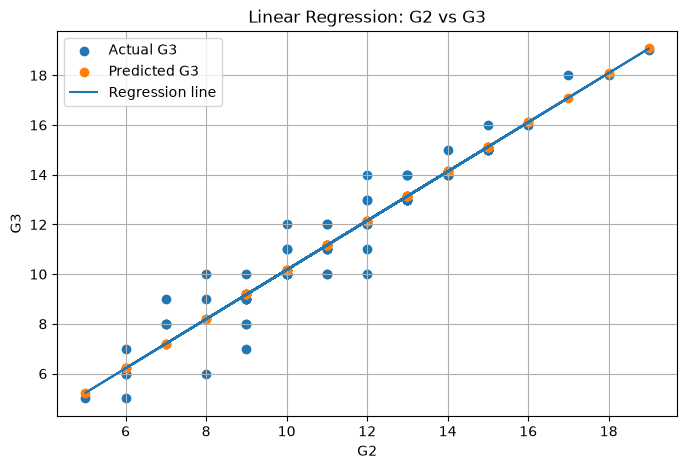

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv("mathematics_grades.csv")

# Define predictor and target
X = df[["G2"]]
y = df["G3"]

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Get coefficients
intercept = model.intercept_
slope = model.coef_[0]

# Print the equation
print("Linear Regression Model:")
print(f"G3 = {intercept:.4f} + {slope:.4f} * G2")

# Interpret the coefficients
print("\nInterpretation:")
print(f"Intercept: {intercept:.4f}")
print("When G2 = 0, the predicted G3 is approximately "
      f"{intercept:.4f}.")

print(f"\nSlope: {slope:.4f}")
print(f"For every 1-point increase in G2, G3 increases by "
      f"approximately {slope:.2f} points on average.")

# Plot actual data and predictions
plt.figure(figsize=(8, 5))

# Actual test data
plt.scatter(
    X_test["G2"],
    y_test,
    label="Actual G3"
)

# Predicted values
plt.scatter(
    X_test["G2"],
    y_pred,
    label="Predicted G3"
)

# Regression line
plt.plot(
    X_test["G2"],
    y_pred,
    label="Regression line"
)

# Labels and title
plt.xlabel("G2")
plt.ylabel("G3")
plt.title("Linear Regression: G2 vs G3")
plt.legend()
plt.grid(True)

plt.show()

The coefficient of G2 is 0.9897, meaning that a one-point increase in G2 is associated with an average increase of approximately 0.99 points in the predicted final grade G3. The intercept is 0.2750, representing the predicted G3 when G2 is zero.

##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

Mean Squared Error (MSE): 7.6908
R-squared (R²): 0.2017


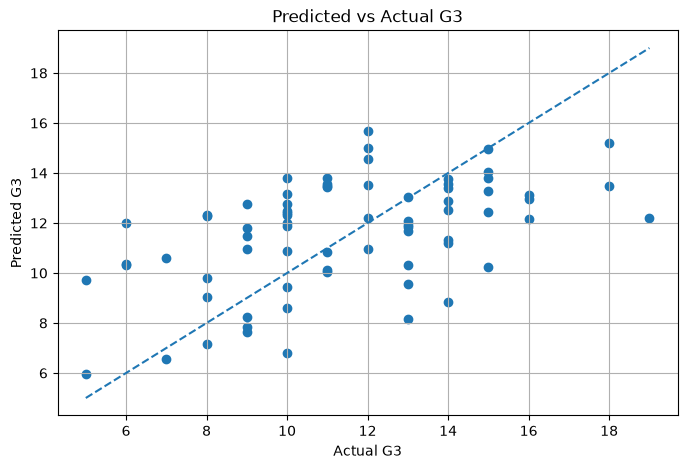

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("mathematics_grades.csv")

# Define predictors and target
# Exclude all variables related to grades
X = df.drop(columns=["G1", "G2", "G3", "failed"])
y = df["G3"]

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=["str"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

# Preprocessing:
# - One-hot encode categorical variables
# - Keep numerical variables unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

# Create the model pipeline
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict G3 for the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

# Plot predicted vs actual values
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual G3")
plt.grid(True)

plt.show()

##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

The main difference is when the model can be used and what information it relies on.

Using previous-period grades (G1/G2): This approach uses a student’s past academic performance to predict their final performance. It is usually more accurate because previous grades are strong indicators of future grades. It is appropriate when G1/G2 are already available, for example, to identify students who may be at risk of failing and provide support before the final assessment.
Using other features: This approach uses factors such as demographic, social, family, and school-related characteristics rather than previous grades. It is useful when previous grades are not yet available, such as at the beginning of the school year. It can help identify potential risk factors and support early intervention.

Therefore, the grades-based model is more suitable for prediction later in the academic process, while the features-based model is more appropriate for earlier prediction and intervention.

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

Cross-validation is a technique used to evaluate how well a machine learning model is likely to perform on unseen data. Instead of evaluating the model using only one train/test split, the available training data is divided into several parts and the model is trained and evaluated multiple times. This gives a more reliable estimate of the model's performance and reduces the risk that the evaluation depends on a particular train/test split.

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

In K-fold cross-validation, the data is divided into \(K\) approximately equal-sized folds. The model is trained using \(K-1\) folds and evaluated on the remaining fold. This process is repeated \(K\) times, so that every fold is used once as the validation set. The final performance is usually calculated as the average of the \(K\) validation results.

Common choices are \(K=5\) or \(K=10\). These values provide a good balance between computational cost and reliable performance estimation. A value that is too small may give a less reliable estimate, while a very large \(K\) increases computational cost and makes the validation sets smaller. Therefore, \(K=5\) or \(K=10\) is generally appropriate.

##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

For logistic regression, the model produces a probability of belonging to the positive class. A classification threshold is then used to convert this probability into a predicted class. Instead of automatically using the default threshold of \(0.5\), K-fold cross-validation can be used to select a threshold that gives the best classification performance.

For each fold, the logistic regression model should be trained on the training folds and predictions should be obtained for the validation fold. For a range of possible thresholds (for example, from 0.1 to 0.9), the predicted probabilities are converted into classes and the chosen performance metric is calculated. This is repeated across all folds, and the performance for each threshold is averaged across the folds.

The threshold with the best average cross-validation performance is then selected. Finally, the logistic regression model can be trained on the complete training dataset using this selected threshold, and the final performance should be evaluated once on the separate test set. This prevents the test set from influencing the choice of threshold and provides an unbiased evaluation of the final model.

# Part 5 - GitHub (1.00)

##### **5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**

Our group used GitHub to track changes throughout the project by regularly **pull** the latest version of the project before making changes, **commit** our own work with a clear description of what was changed, and then **push** the changes back to the shared repository. This allowed all group members to stay updated and ensured that the latest version of the project was available to everyone.

Maintaining a clear change history is important because it allows us to see what changes were made, when they were made, and by whom. It also makes it easier to identify and fix mistakes, recover previous versions, and understand how the analysis and machine learning models developed throughout the project. This improves collaboration, transparency, and reproducibility.
